In [76]:
%reset -f
from sklearn.datasets import fetch_california_housing
import numpy as np
import copy
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
torch.manual_seed(0)
np.random.seed(0)
torch.use_deterministic_algorithms(False) # problem with cuda

use_cuda=torch.cuda.is_available()
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
device = get_default_device()
device 



In [77]:
data = fetch_california_housing()
print(data.feature_names)
X, y = data.data, data.target

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [78]:
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset = train_dataset, batch_size = 100, shuffle=False) # small batch size
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(dataset = test_dataset, batch_size = 100, shuffle=False) # small batch size

In [79]:
n_train = len(y_train)
n_train

14447

In [80]:
# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(8, 24), # eight inputs
            nn.ReLU(),
            nn.Linear(24, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU(),
            nn.Linear(6, 1) # one output
        )
    
    def forward(self, x):
        output = self.linear_relu_stack(x)
        return output

model = NeuralNetwork().to(device=device) # model to cuda
print(model)

# loss function and optimizer
loss_fn = nn.MSELoss(reduction='sum')  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.01)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=6, bias=True)
    (5): ReLU()
    (6): Linear(in_features=6, out_features=1, bias=True)
  )
)


In [81]:
# training parameters
n_epochs = 50   # number of epochs to run

history = []
best_mse = np.inf   # init to infinity
best_weights = None
# training loop

start_time = time.time()
for epoch in range(n_epochs):
    model.train() # tell pytorch you are training
    train_err = 0
    for X_batch, y_batch in train_loader:
        # forward pass
        X_batch, y_batch = X_batch.to(device=device), y_batch.to(device=device) # data to cuda
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()
        train_err = train_err + float(loss)
    train_err = train_err / len(train_dataset)

    # evaluate accuracy at end of each epoch
    model.eval() # tell pytorch you are testing
    mse = 0 
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device=device), y_test.to(device=device) # data to cuda
        y_pred = model(X_test)
        loss = loss_fn(y_pred, y_test)
        mse = mse + float(loss)
    mse = mse / len(test_dataset)

    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    
    print(f"Epoch: {epoch+1}, Train Err: {train_err:.3f}, Test Err: {mse:.3f}")   
    history.append([mse, train_err])

time_used = (time.time() - start_time)
print(f"--- {time_used:.2f} seconds ---")
print(f"--- {n_epochs*n_train / time_used:.2f} samples per seconds ---")

# restore model and return best accuracy
model.load_state_dict(best_weights)

Epoch: 1, Train Err: 45.313, Test Err: 1.270
Epoch: 2, Train Err: 1.212, Test Err: 1.142
Epoch: 3, Train Err: 1.121, Test Err: 0.999
Epoch: 4, Train Err: 0.927, Test Err: 0.788
Epoch: 5, Train Err: 0.709, Test Err: 1.156
Epoch: 6, Train Err: 0.885, Test Err: 1.174
Epoch: 7, Train Err: 0.926, Test Err: 0.639
Epoch: 8, Train Err: 0.677, Test Err: 0.647
Epoch: 9, Train Err: 0.735, Test Err: 0.606
Epoch: 10, Train Err: 0.700, Test Err: 0.662
Epoch: 11, Train Err: 0.685, Test Err: 0.724
Epoch: 12, Train Err: 0.622, Test Err: 0.723
Epoch: 13, Train Err: 0.598, Test Err: 0.740
Epoch: 14, Train Err: 0.594, Test Err: 0.615
Epoch: 15, Train Err: 0.736, Test Err: 0.595
Epoch: 16, Train Err: 0.778, Test Err: 0.573
Epoch: 17, Train Err: 0.572, Test Err: 0.536
Epoch: 18, Train Err: 0.597, Test Err: 0.584
Epoch: 19, Train Err: 0.747, Test Err: 0.536
Epoch: 20, Train Err: 0.566, Test Err: 0.542
Epoch: 21, Train Err: 0.651, Test Err: 0.515
Epoch: 22, Train Err: 0.543, Test Err: 0.504
Epoch: 23, Train E

<All keys matched successfully>

In [42]:
print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor])

Model's state_dict:
tensor([[-2.6470e-03,  1.8966e-01, -2.9099e-01, -2.6019e-01, -1.3617e-01,
          9.4808e-02, -7.0050e-03,  2.8033e-01],
        [-3.1376e-02,  9.3555e-02, -1.0685e-01, -6.9496e-02, -3.3777e-01,
         -2.3415e-01, -1.4574e-01,  1.3097e-02],
        [ 2.8995e+00,  8.6600e-01, -1.0989e+00, -2.9819e-01, -4.2959e-02,
         -1.2640e+00, -2.1269e-01,  2.9942e-01],
        [-5.6987e-02,  3.7411e-02,  3.2013e-01, -3.2798e-01, -2.2258e-01,
         -8.9507e-02, -1.3782e-01,  3.0547e-01],
        [-2.2917e-01, -1.6275e-01, -2.4701e-01, -3.3112e-01, -2.0638e-01,
          3.0391e-01,  1.5776e-01,  1.7136e-01],
        [ 1.8594e-02, -1.8126e-01,  5.9816e-02, -3.3011e-01, -2.5547e-01,
         -1.8227e-01,  2.2307e-01,  2.0730e-01],
        [ 2.7193e-01, -6.4254e-01,  3.9590e-01,  1.1034e+00, -1.8725e-01,
         -1.1615e+00, -7.9194e-02, -3.3142e-02],
        [-1.6234e+00, -1.2242e+00, -1.4626e+00, -1.1130e+00, -5.4928e-03,
         -4.4918e-01, -1.2080e+00,  1.0655e+0

MSE: 0.48
RMSE: 0.69


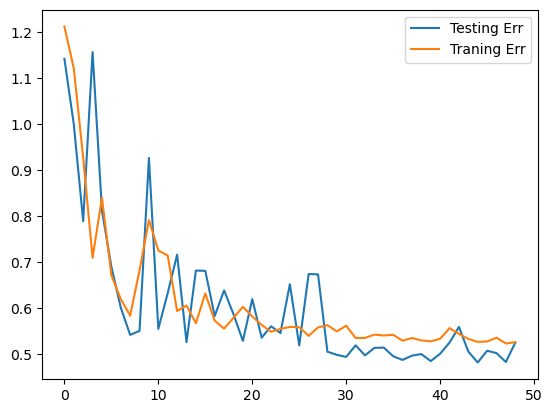

In [75]:
import matplotlib.pyplot as plt
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history[1:])
plt.legend(["Testing Err", "Traning Err"])
plt.show()

1.2118853903513198